# 07 · 算法综合训练


来源：[飞书讲义《第7章：算法综合训练》](https://heuqqdmbyk.feishu.cn/docx/JfSmdxCqIoQ2ANxLF82cJdu8nmd) · 整理日期：2026-09-26。

按讲义原顺序保留 6 道综合练习的全部需求、思路分析、6 段代码和 18 张配图。必要的“勘误”和“补充”在对应内容旁单独标明。每个示例类应单独保存；使用 `Random`、`Scanner` 的示例需在类定义之前添加 `import java.util.Random;`、`import java.util.Scanner;`。本章的 `Random.nextInt(起点, 终点)` 写法需要 JDK 17 或更新版本，取值包含起点、不包含终点。


> 大家学习中如果碰到任何的困难(BUG、学习规划、学习资料等)，都可以加入<a href="https://heuqqdmbyk.feishu.cn/docx/ZZ4MdTFkaou4m7x4bVLcpOc7nRf"><strong>黑马智学伴侣</strong></a><a href="https://heuqqdmbyk.feishu.cn/docx/ZZ4MdTFkaou4m7x4bVLcpOc7nRf"><strong>(有问题点我)</strong></a>寻求帮助，有学习交流群，老师、同学在线答疑。还有独享的企业级项目，避免与人撞车。

到目前为止，我们已经把Java的核心语法学习完毕了，接下来我们做一些综合训练题提高大家的编程思维，其中有复杂业务的逻辑题，也有力扣、牛客上面的算法真题。难度较大，希望兄弟姐妹们仔细思考里面的每一个细节，独立完成代码。

> <strong>本章节内容会不断更新，大家不需要下载，在线观看即可。</strong>


## 综合练习一：移除元素

### <strong>需求：</strong>

给你一个数组 nums 和一个值 val，你需要删除所有数值等于 val 的元素

举例1：

输入：nums = &#91;3,2,2,3&#93;    val = 3

输出：nums = &#91;2,2&#93;  剩余2个元素

举例1：

输入：nums = &#91;0,1,2,2,3,0,4,2&#93;    val = 2

输出：nums = &#91;0,1,4,0,3&#93;  剩余5个元素

### <strong>思路分析：</strong>

1. 假设数组中的数据：2, 2, 1, 1, 2, 2, 3, 3, 3, 3，删除2之后：1, 1, 3, 3, 3, 3
2. 我们可以利用双指针，也叫做快慢指针实现
3. 慢指针:存入的位置
4. 快指针:找数字2
5. 比较两个指针对应的数据，如果是2，舍弃快指针位置的数据。如果不是2，快指针的数据存入慢指针位置。

> **勘误：**这里实际比较的是快指针处的元素 `arr[fast]` 与待删除值 `val`，不需要比较 `arr[slow]` 与 `arr[fast]`。只有 `arr[fast] != val` 时，才把该元素写到 `slow` 位置，并增加有效元素个数。

如图所示：

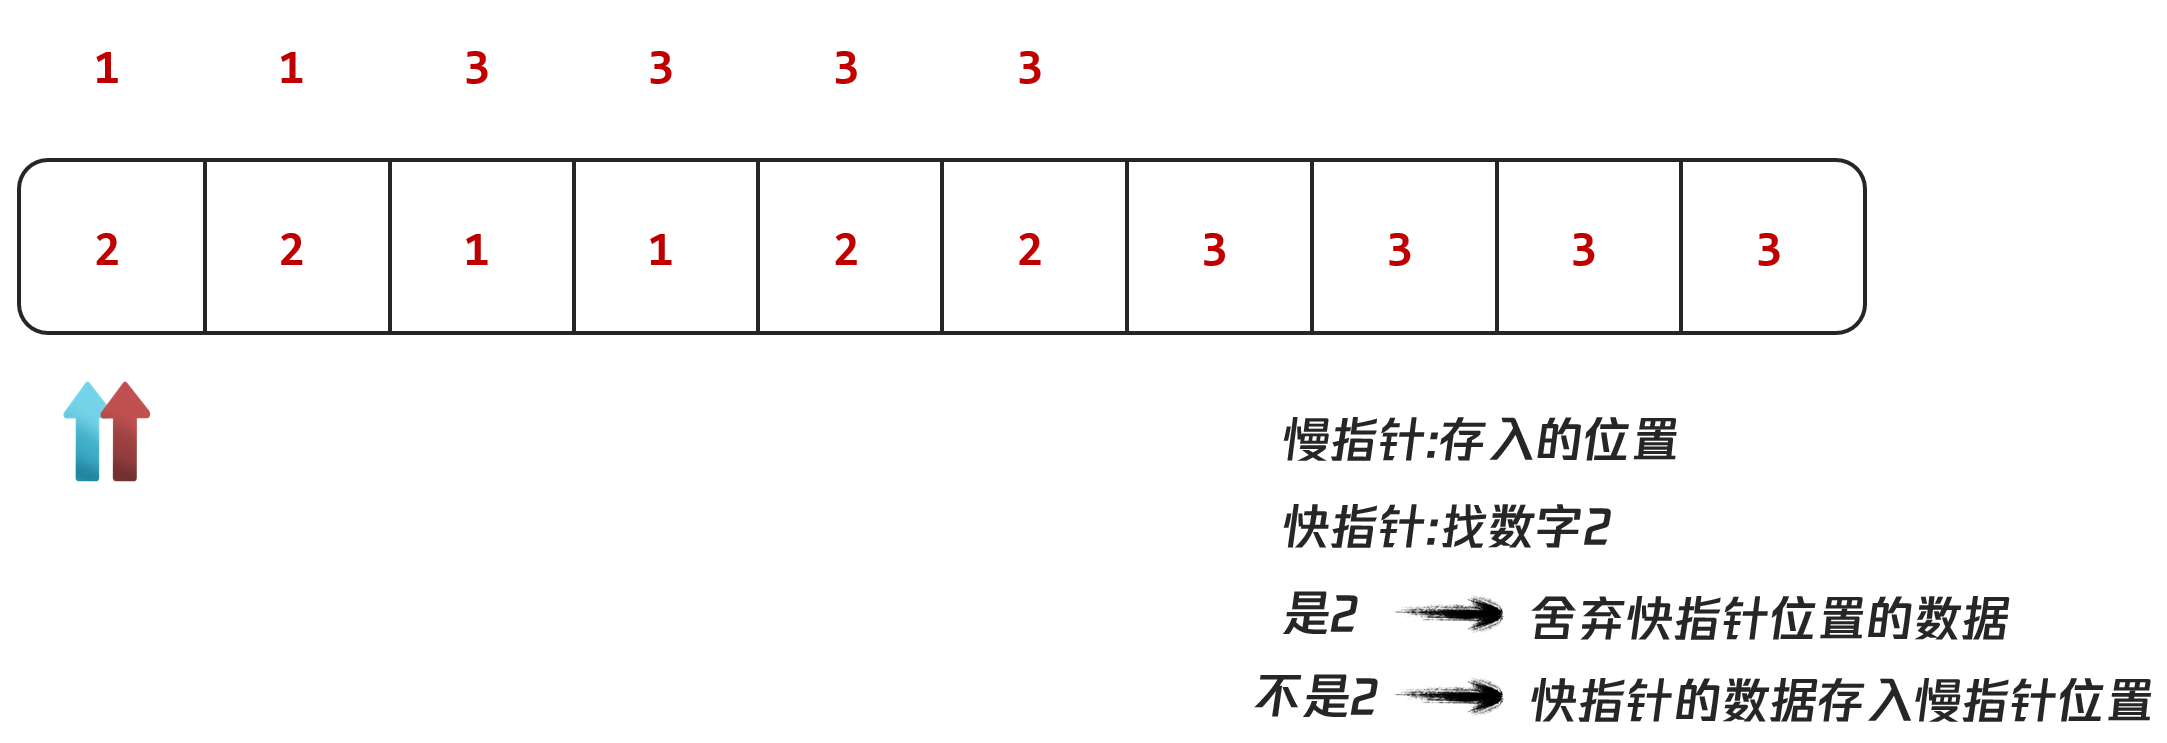

### <strong>代码示例：</strong>

````java
public class Test1 {
    public static void main(String[] args) {
       /*
            给你一个数组 nums 和一个值 val，你需要删除所有数值等于 val 的元素
            举例1：
            输入：nums = [3,2,2,3]    val = 3
            输出：nums = [2,2]  剩余2个元素
            举例1：
            输入：nums = [0,1,2,2,3,0,4,2]    val = 2
            输出：nums = [0,1,4,0,3]  剩余5个元素
       */
        // 1. 定义数组
        int[] arr = {0, 1, 2, 2, 3, 0, 4, 2};
        // 2. 定义一个变量表示要删除的数据
        int val = 2;

        // 3. 利用快慢指针去删除数据
        int slow = 0;
        int fast = 0;

        while (fast < arr.length){
            // 4. 判断当前快指针指向的元素是否为2
            if(arr[fast] != val){
                // 不相等
                // 如果快指针当前的位置不是2,那么就把这个数字存入到慢指针的位置, 慢指针,快指针往后移动一位
                arr[slow] = arr[fast];
                slow++;
            }
            fast++;
        }

        // 5. 遍历数组
        for (int i = 0; i < slow; i++) {
            System.out.print(arr[i] + " ");
        }
        System.out.println();

        System.out.println("有效个数有:" + slow);


    }
}
````

> **补充：**本例是原地覆盖，数组物理长度不变；结果只看前 `slow` 个元素，后面保留的旧值不再属于有效结果。代码保留未删除元素的原顺序，因此第二组数据实际输出 `0 1 3 0 4`，有效个数为 `5`。题干的 `0 1 4 0 3` 是忽略元素顺序时的另一种结果。


## 综合练习二：红包问题

### <strong>需求：</strong>

给你两个整数M和N，M表示红包的总额， N表示红包的个数

现在又N个人来抽红包，每个人都是随机的，打印每个人领的红包金额

### <strong>思路分析：</strong>

本道题不是单纯随机就可以的，假设200元5个红包，直接5次随机有可能会遇到很多问题：

1. 前面的人把钱都领完了，后面的人领不到了
2. 5个人随机的总额不是红包总额

注意本题的几个坑：

1. 每个人最少1分钱
2. 每个人领完红包之后，至少预留 1  &#42;  N 分钱

> 第一个人：至少预留4分钱
> 
> 第二个人：至少预留3分钱
> 
> 第三个人：至少预留2分钱
> 
> 第四个人：至少预留1分钱

1. 最后一个人是拿剩余的总额，不随机

### <strong>代码示例：</strong>

````java
public class Test2 {
    public static void main(String[] args) {
       /*
            给你两个整数M和N，M表示红包的总额， N表示红包的个数
            现在又N个人来抽红包，每个人都是随机的，打印每个人领的红包金额

            要求1：每个人最少1分钱
            要求2：每个人领完红包之后，至少预留 1  *  N 分钱
            要求3：最后一个人是拿剩余的总额
       */
        // 1.定义变量表示红包的总额
        int money = 20000;// 分

        // 2.定义变量表示红包的个数
        int n = 5;

        // 判断红包的金额要足够
        if(money < n){
            System.out.println("红包金额不够,请充值~");
        }else{
            // 3.利用循环抽取红包
            Random r = new Random();
            for (int i = 1; i <= n - 1; i++) {
                // 利用Random进行随机抽取   1 2 3 4 表示当前是第几个人抽取
                //                        4 3 2 1 表示最少预留的钱,单位分
                //                        money - (n - i)
                //                      第一个人抽取红包: 20000 - (5 - 1)

                // money - (n - i) : 目的为了给后面的人预留至少一分钱
                // +1 : 目前保证自己最少抽取一分钱
                int myMoney = r.nextInt(money - (n - i)) + 1;

                // 从总额中减去当前抽取到的钱
                money = money - myMoney;

                System.out.println("第" + i + "个人，抢到" + myMoney + "分");
            }

            // 4. 输出最后一个人抢到的钱
            System.out.println("第" + n + "个人，抢到" + money + "分");
        }
    }
}
````

> **补充：**`money` 的单位是“分”，`20000` 分就是 `200` 元。若把固定数据改成用户输入，还需保证 `n > 0` 且 `money >= n`。第 `i` 人领取时，后面剩 `n - i` 人，因此本轮允许的最大金额为 `money - (n - i)`，最后一人领取余额。这个算法保证金额守恒、每人至少一分，但不保证先后领取者的金额分布相同。


## 综合练习三：中位数

### <strong>需求：</strong>

给定两个正序数组 arr1和 arr2，请先合并数组，并找出合并之后数组的中位数。

举例： 

1 2 3 4 5 6 7 8 9      中位数：5

1 2 3 4 5 6           中位数： （ 3 + 4 ） / 2 

### <strong>思路分析：</strong>

1. 本题可采取二路归并思想
2. 比较两个指针位置的数据，把小的放到大数组中即可

注意本题的坑：

如果数组长度不一样，当A数组全部存完，另外一个数组就不需要比较了，直接存入即可

### <strong>代码示例：</strong>

````java
package com.itheima.test;

public class Test3 {
    public static void main(String[] args) {
        /*
            给定两个正序数组arr1和arr2，请先合并数组，并找出合并之后数组的中位数。
            举例：
            1 2 3 4 5 6 7 8 9       中位数：5
            1 2 3 4 5 6            中位数： （ 3 + 4 ） / 2
        */

        int[] arr1 = {1,2,3,4,5};
        int[] arr2 = {2,3,4,5,6};
        double res = findMedianSortedArrays(arr1, arr2);
        System.out.println(res);
    }

    public static double findMedianSortedArrays(int[] nums1, int[] nums2) {
        int len1 = nums1.length;
        int len2 = nums2.length;
        int len = len1 + len2;
        int[] arr = new int[len];
        int index1 = 0;
        int index2 = 0;
        for (int i = 0; i < len; i++) {
            if(index1 == len1){
                arr[i] = nums2[index2];
                index2++;
                continue;
            }
            if(index2 == len2){
                arr[i] = nums1[index1];
                index1++;
                continue;
            }
            if(nums1[index1] < nums2[index2]){
                arr[i] = nums1[index1];
                index1++;
            }else{
                arr[i] = nums2[index2];
                index2++;
            }
        }

        if(len % 2 == 0){
            double num1 = arr[len / 2 - 1];
            double num2 = arr[len / 2];
            return (num1 + num2) /2;
        }else{
            //奇数
            //1 2 3 4 5
            //0 1 2 3 4
            return arr[(len - 1) / 2];
        }
    }
}
````

> **补充：**两个输入数组必须已按升序排列，并且总长度大于 `0`。允许其中一个数组为空；若两个都为空，中位数无定义，代码会访问非法索引。本例合并后为 `1, 2, 2, 3, 3, 4, 4, 5, 5, 6`，两个中间数是 `3` 和 `4`，结果为 `3.5`。


## 综合练习四：统计个数

### <strong>需求：</strong>

学校选举学生会主席，有5个候选人

全校1000名同学参与投票（每人一票，可以弃权，或者选1-5号）。

投票使用Random模拟。0：弃权，1 &#126; 5：给对应的候选人投票

要求1：

统计每个候选人的得票数和得票率，找出得票最多的候选人？

要求2：

统计弃票数和弃票率是多少？

### <strong>思路分析：</strong>

1. 本题是利用数组进行统计
2. 数组中每个位置统计的内容是不一样的

如图所示：

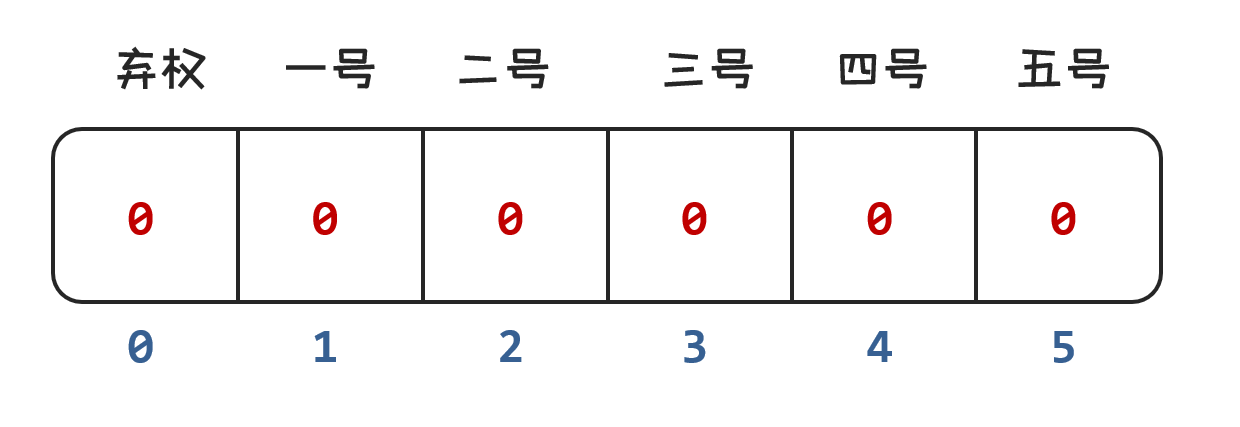

### <strong>代码示例：</strong>

````java
public class Test4 {
    public static void main(String[] args) {
        /*
             学校选举学生会主席，有5个候选人
             全校1000名同学参与投票（每人一票，可以弃权，或者选1-5号）。
             投票使用Random模拟。
                0：弃权
                1 ~ 5：给对应的候选人投票

             要求1：
                统计每个候选人的得票数和得票率，并找出票最多的候选人？
             要求2：
                统计弃票数和弃权率是多少？


             利用数组进行统计
         */

        // 1.创建一个长度为6的数组， 0索引统计弃票的人数 1-5索引统计每个候选人的票数
        int[] arr = new int[6];

        // 2.循环1000次，生成投票数据
        //  0：弃票
        //  1：一号
        //  2：二号
        //  3：三号
        //  4：四号
        //  5：五号
        Random r = new Random();
        for (int i = 0; i < 1000; i++) {
            // 生成投票的数据 0 ~ 5
           int vote = r.nextInt(0,6);
           // 要把投票的数据放入到数组当中
            // vote: 含义一: 投票的数据
            //       含义二: 数组的索引
            arr[vote]++;
        }
        
        // 3.统计每个候选人的得票数和得票率
        for (int i = 1; i < arr.length; i++) {
            System.out.println("第" + i + "个候选人的得票数是：" + arr[i] + "，得票率是：" + arr[i] * 1.0 / 1000 * 100 + "%");
        }

        // 4.找出最多的票数(最大值)
        int max = arr[1];
        for (int i = 2; i < arr.length; i++) {
            if(max < arr[i]){
                max = arr[i];
            }
        }

        // 5. 找出票最多的候选人
        // 有可能发生一种情况: 多个候选人的票数相同
        for (int i = 1; i < arr.length; i++) {
            if(arr[i] == max){
                System.out.println("第" + i + "个候选人的票数是最多的,共计：" + arr[i] + "张票");
            }
        }

        // 6.统计弃票数和弃权率是多少
        // arr[0]
        System.out.println("弃票数是：" + arr[0] + "，弃权率是：" + arr[0] * 1.0 / 1000 * 100 + "%");
    }
}
````


## 综合练习五：接雨水

### <strong>需求：</strong>

给定 n 个非负整数表示每个宽度为 1 的柱子的高度图，计算按此排列的柱子，下雨之后能接多少雨水

输入：height = &#91;0,1,0,2,1,0,1,3,2,1,2,1&#93;

输出：6

解释：下面是由数组 &#91;0,1,0,2,1,0,1,3,2,1,2,1&#93; 表示的高度图，在这种情况下，可以接 6 个单位的雨水（蓝色部分表示雨水）

### <strong>思路分析：</strong>

1. 本题利用动态规划DP思想，把大问题拆成小问题，再找到大问题的最优解。
2. 要注意的是数组里面每一个数字，其实就是柱子的高度

> 0：高度为0
> 
> 1：高度为1
> 
> 2：高度为2

如图所示：

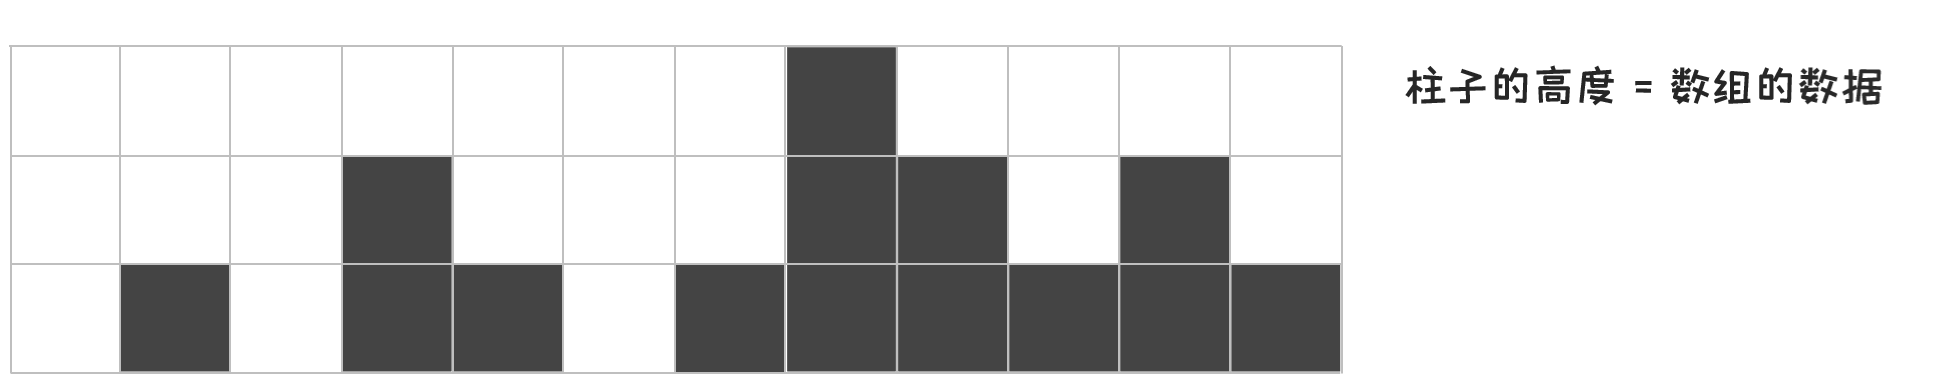

1. 柱子有了，接下来就下雨，问题就是，雨停了，蓝色表示的水能留下多少？

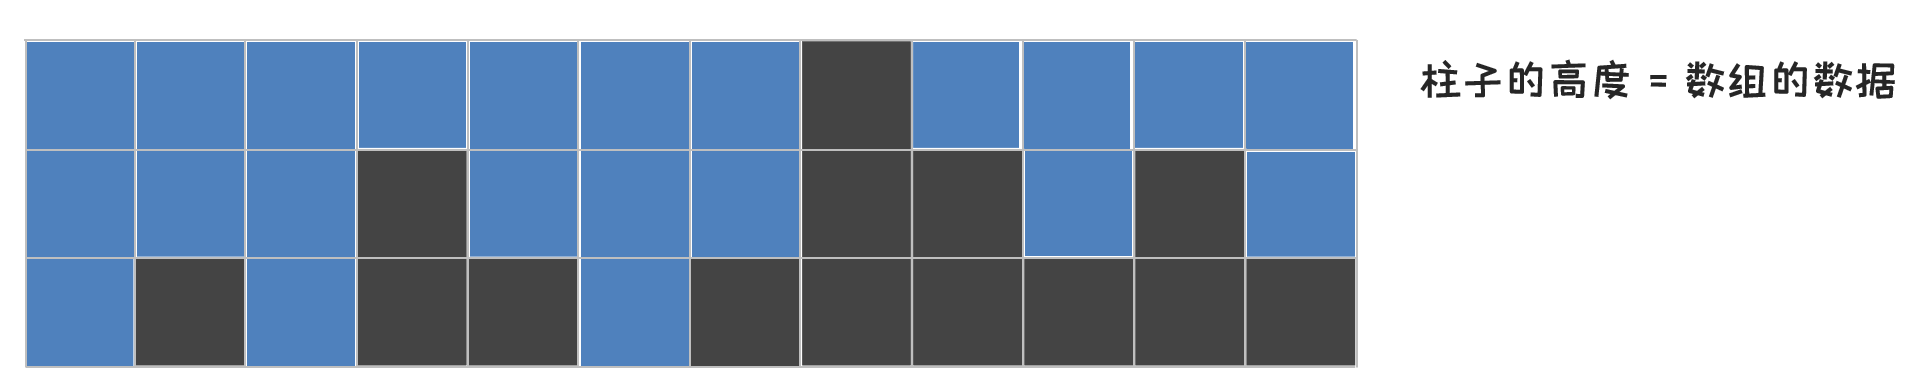

1. 雨水留下的核心其实就是看左边和右边有没有柱子挡着，如果有，雨水能留下，如果没有雨水流走。最终能留下的雨水如图所示：

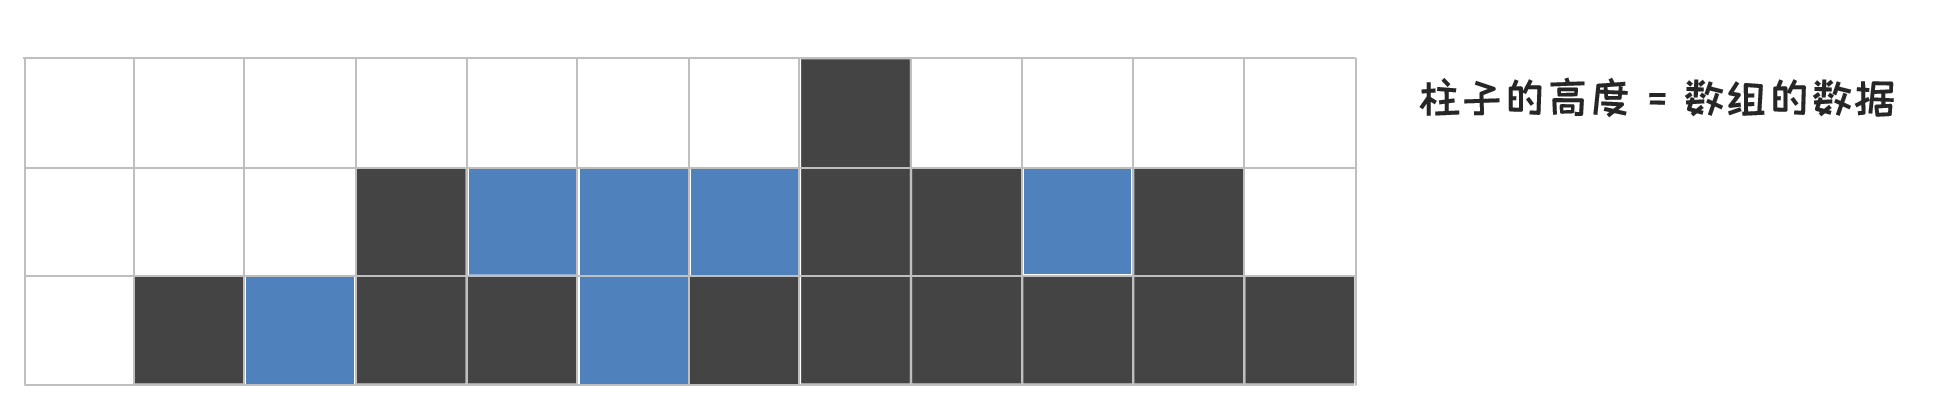

1. 既然雨水是否留下看左右的柱子，那么我们就可以把问题拆成两部分，

    1. 假设右边有一个无限高的柱子，水无法从右边流走，只能从左边流走。
    2. 假设左边有一个无限高的柱子，水无法从左边流走，只能从右边流走。
    3. 再计算两个的交集就能得到最终的结果。

2. 假设右边有无限高的柱子的情况，如图所示：

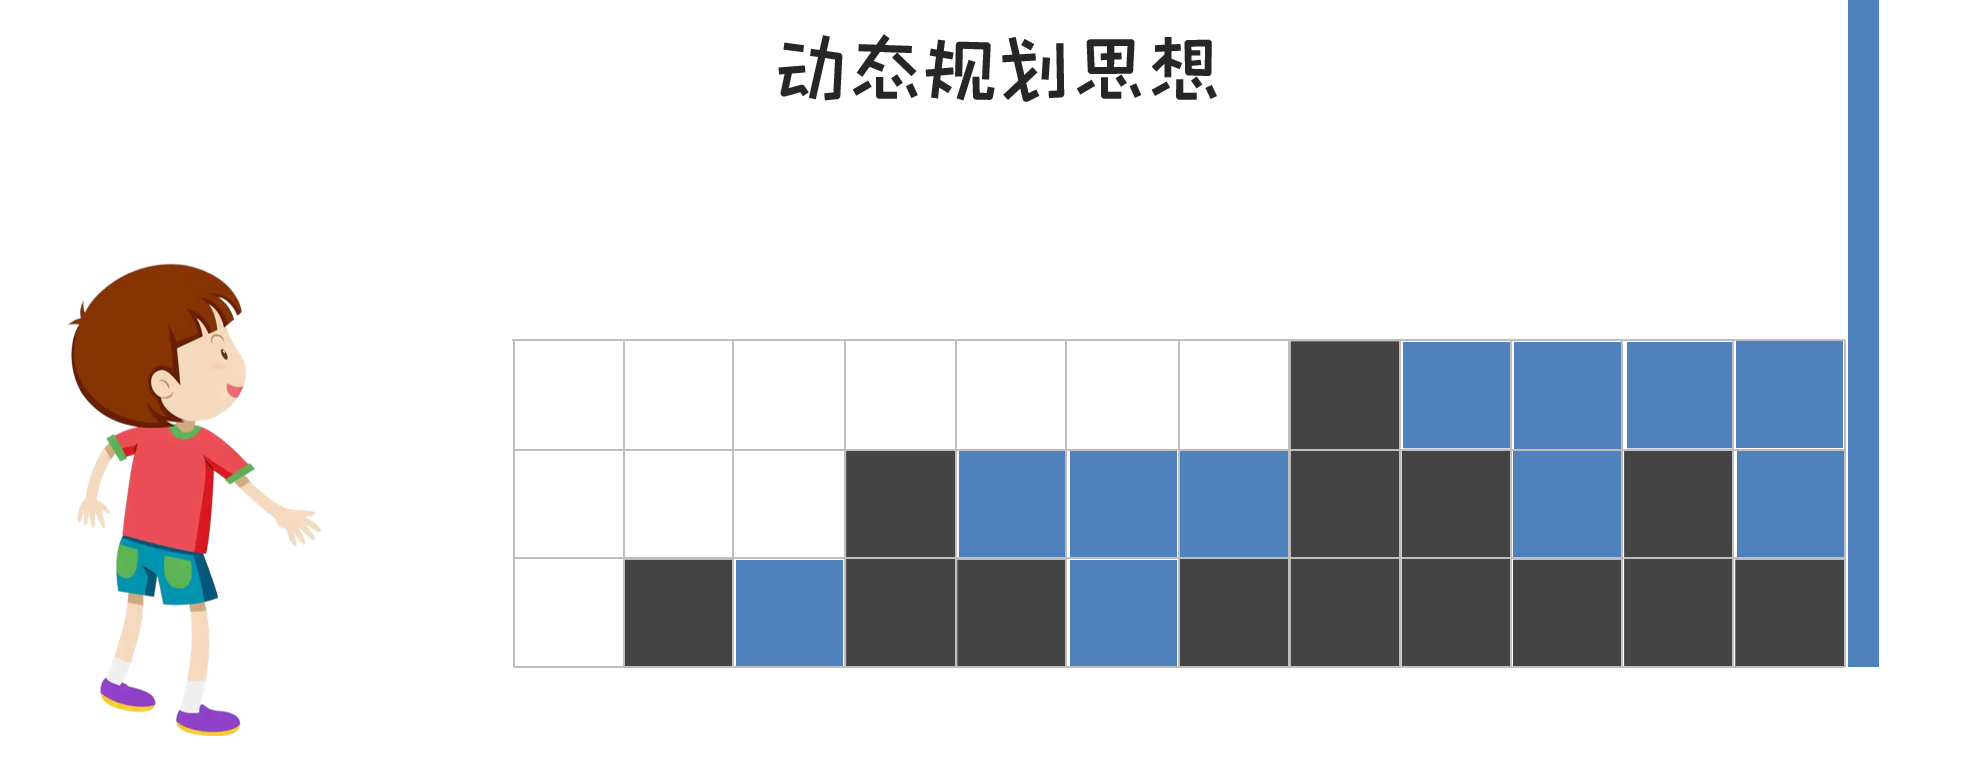

相当于此时，有人从左往右看有多少单位的雨水能留下

1. 假设左边有无限高的柱子的情况，如图所示：

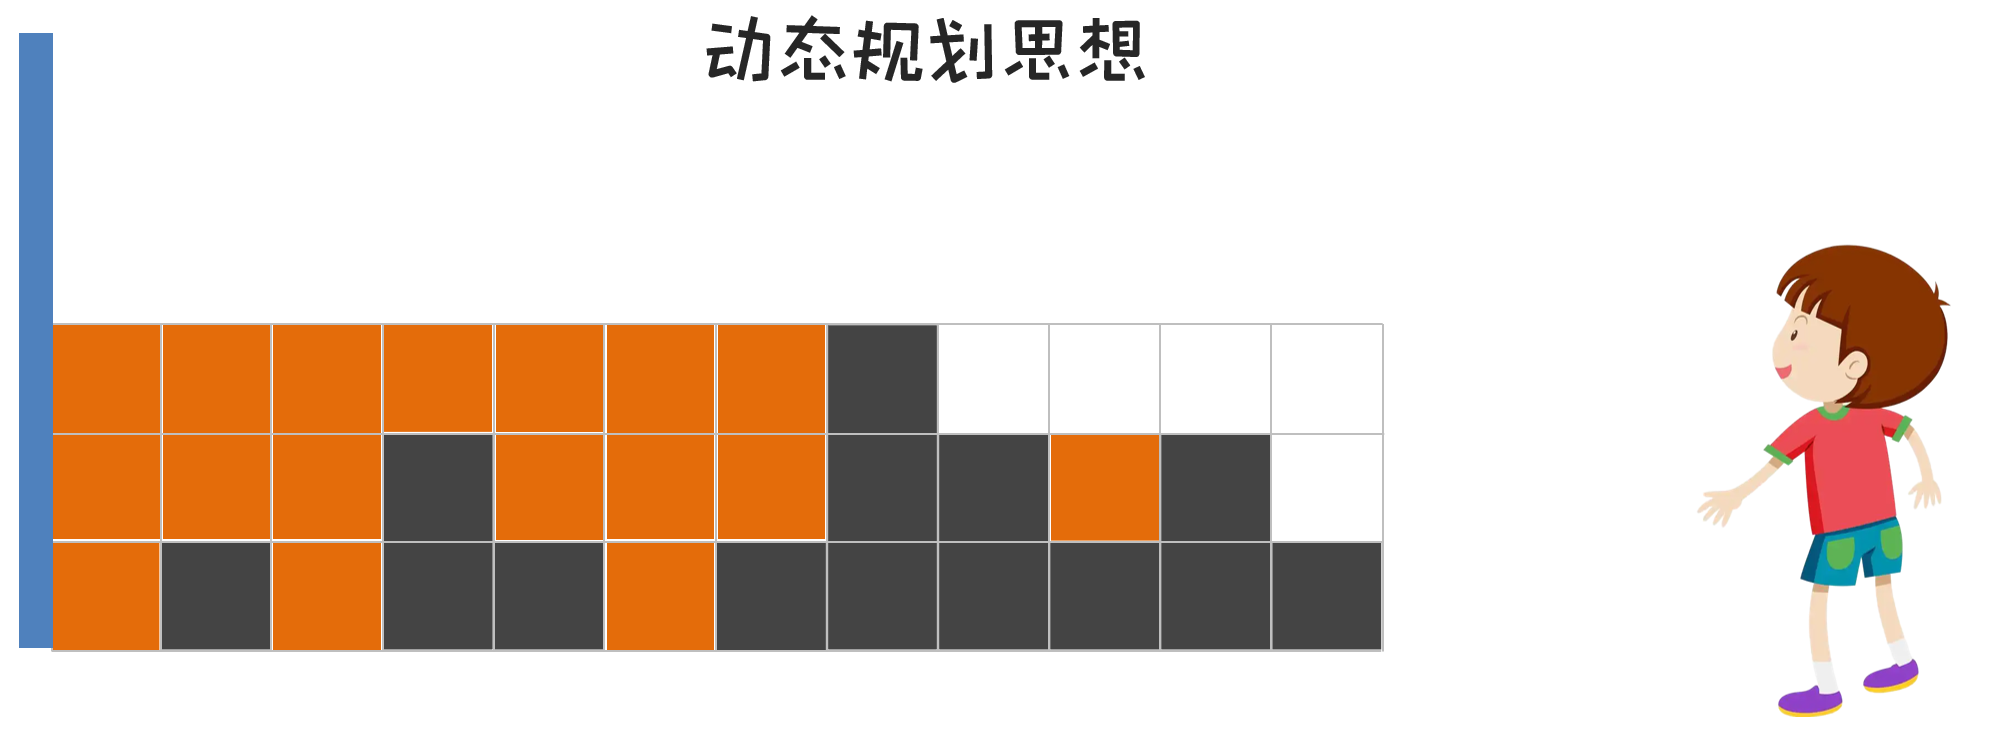

相当于此时，有人从右往左看有多少单位的雨水能留下

1. 合并，取交集

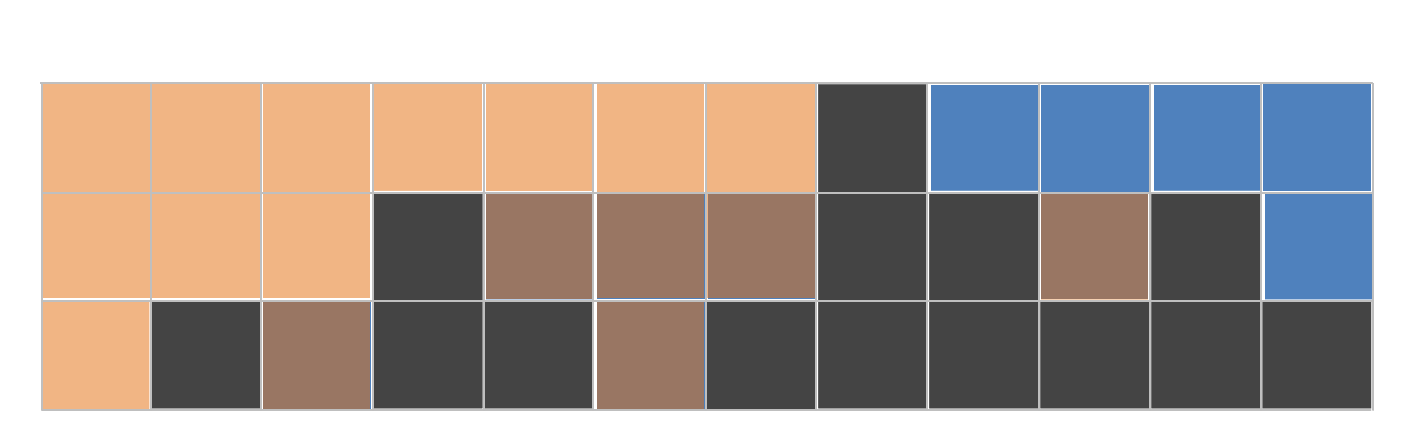

### 代码解析：

先来看从左往右看的情况，直接统计蓝色的雨水不方便，我们可以先统计柱子加雨水总单位，最后再减去柱子的面积即可。最终，我想记录的结果是 0 1 1 2 2 2 2 3 3 3 3，如图所示：

> **勘误：**原文这组数少写了最后一个 `3`。输入有 12 个元素，完整的 `leftMax` 是 `[0, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3]`。其中 `leftMax[i]` 表示从索引 `0` 到 `i` 的最高柱子，`rightMax[i]` 表示从索引 `i` 到末尾的最高柱子；单个位置的积水量是 `Math.min(leftMax[i], rightMax[i]) - arr[i]`。

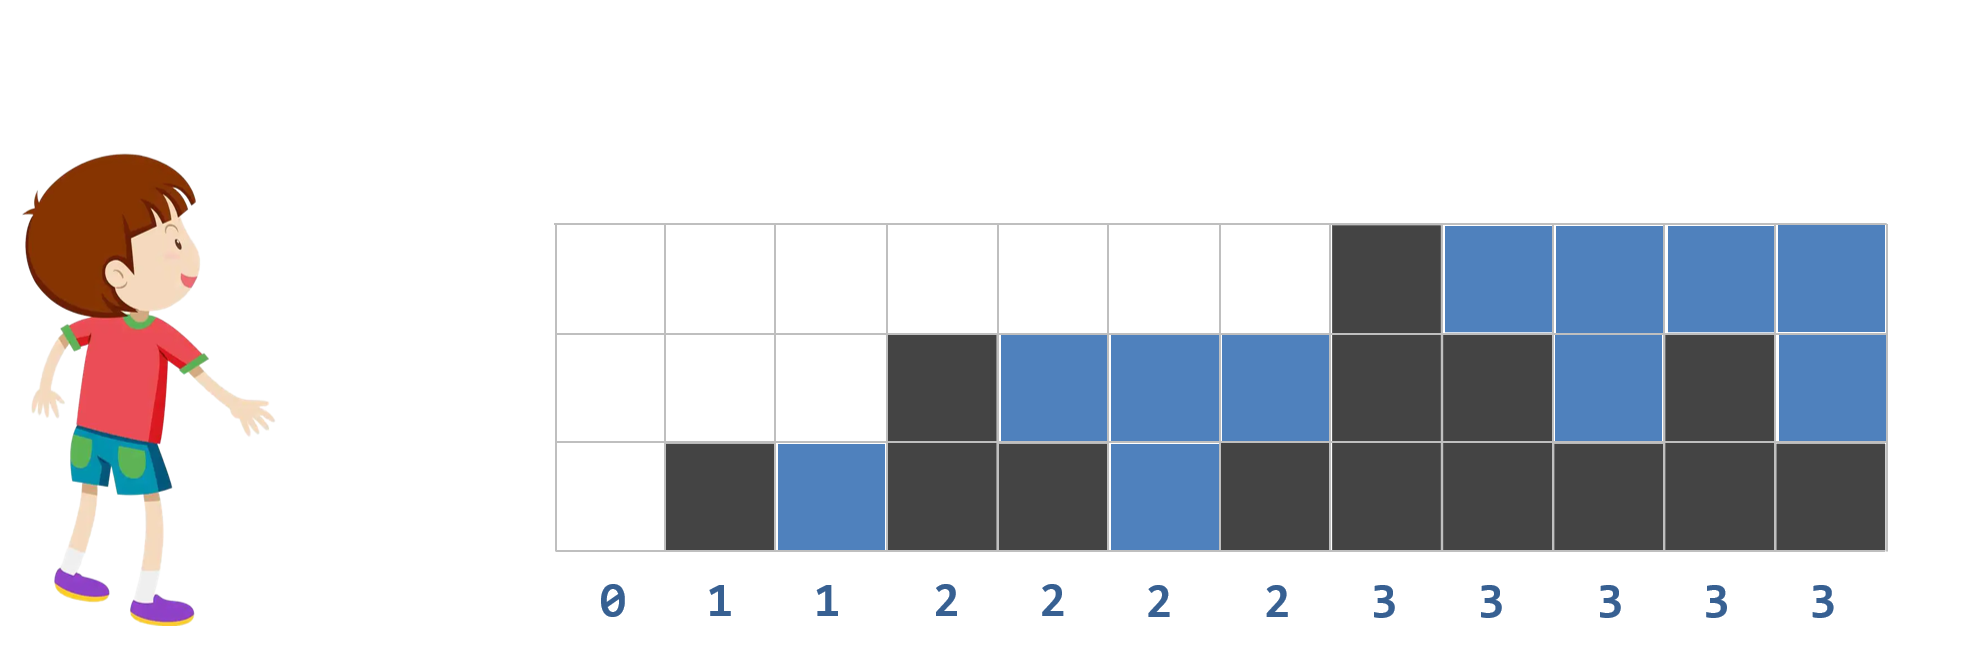

具体实现步骤如下：

1. 第三方变量，这个变量表示，目前最高的柱子。第一个柱子，高度为0，变量就记录0。

如图所示：

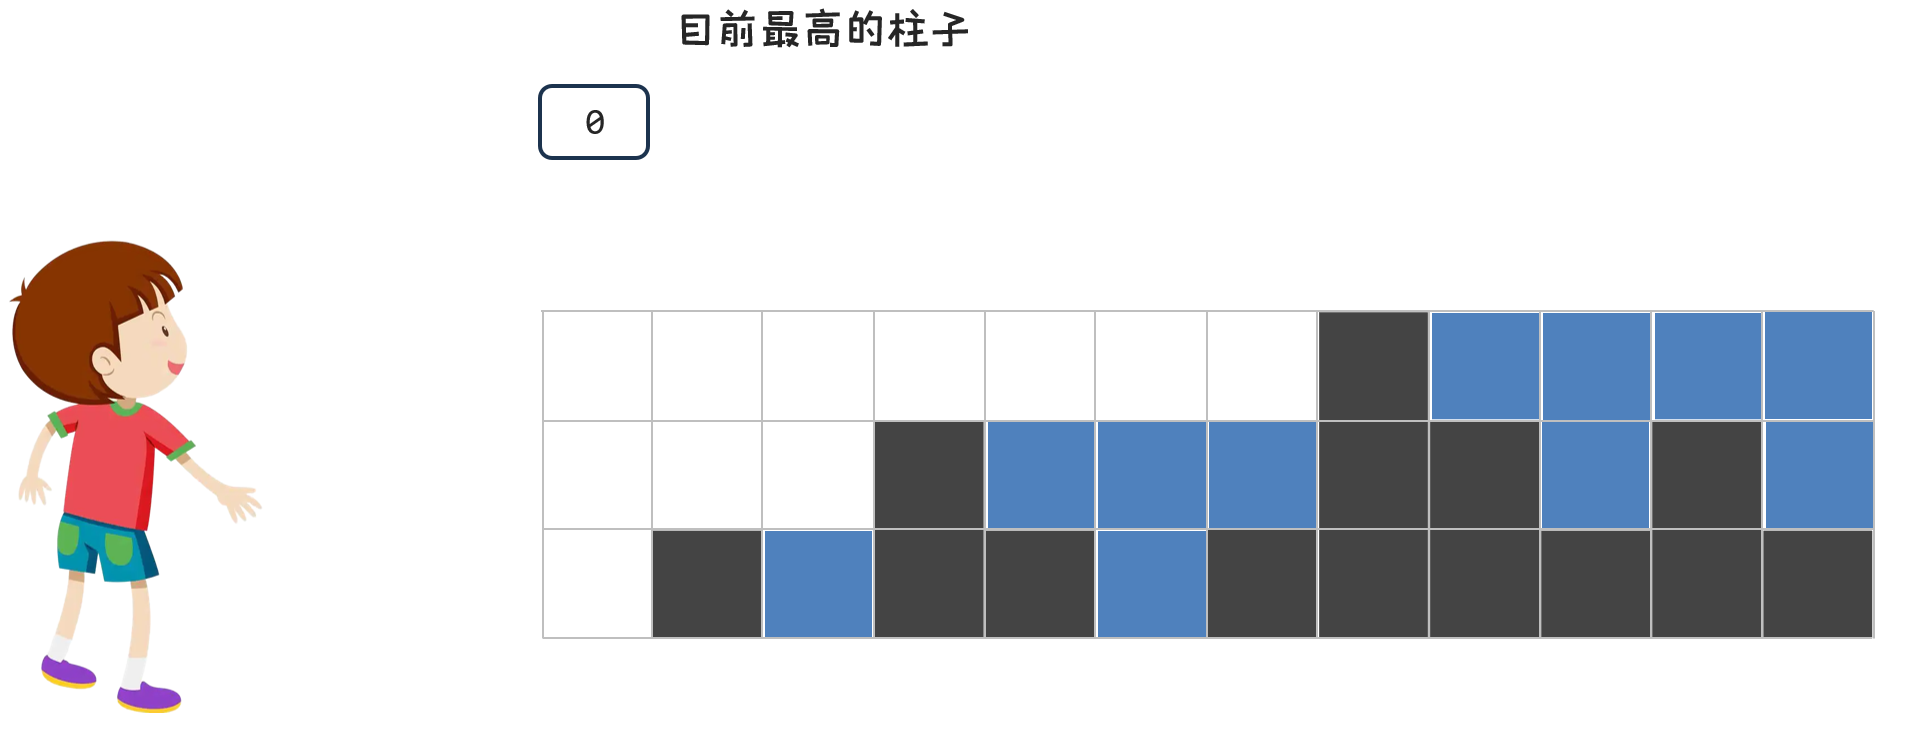

1. 拿着他跟后面的数据进行比较，记录当前柱子和雨水的总和。

如果遇到更高的柱子，就记录柱子的高度。

如果遇到更矮的柱子，就记录当前变量中记录的数据。

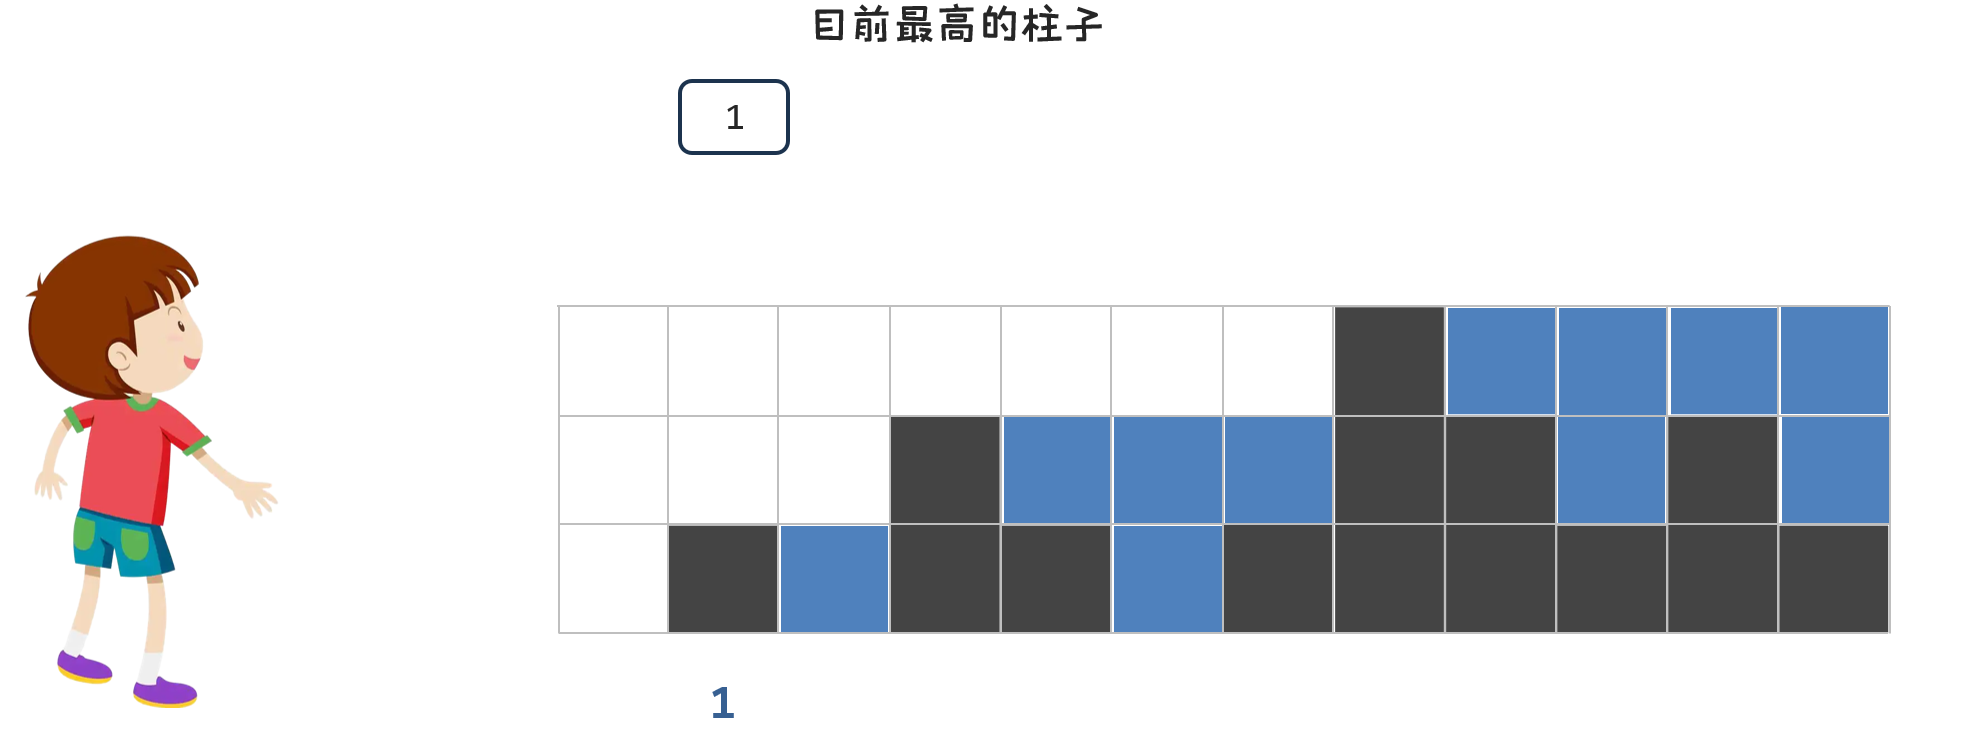

1. 当所有的数据比较完毕之后，从左往右看的就已经统计完毕。

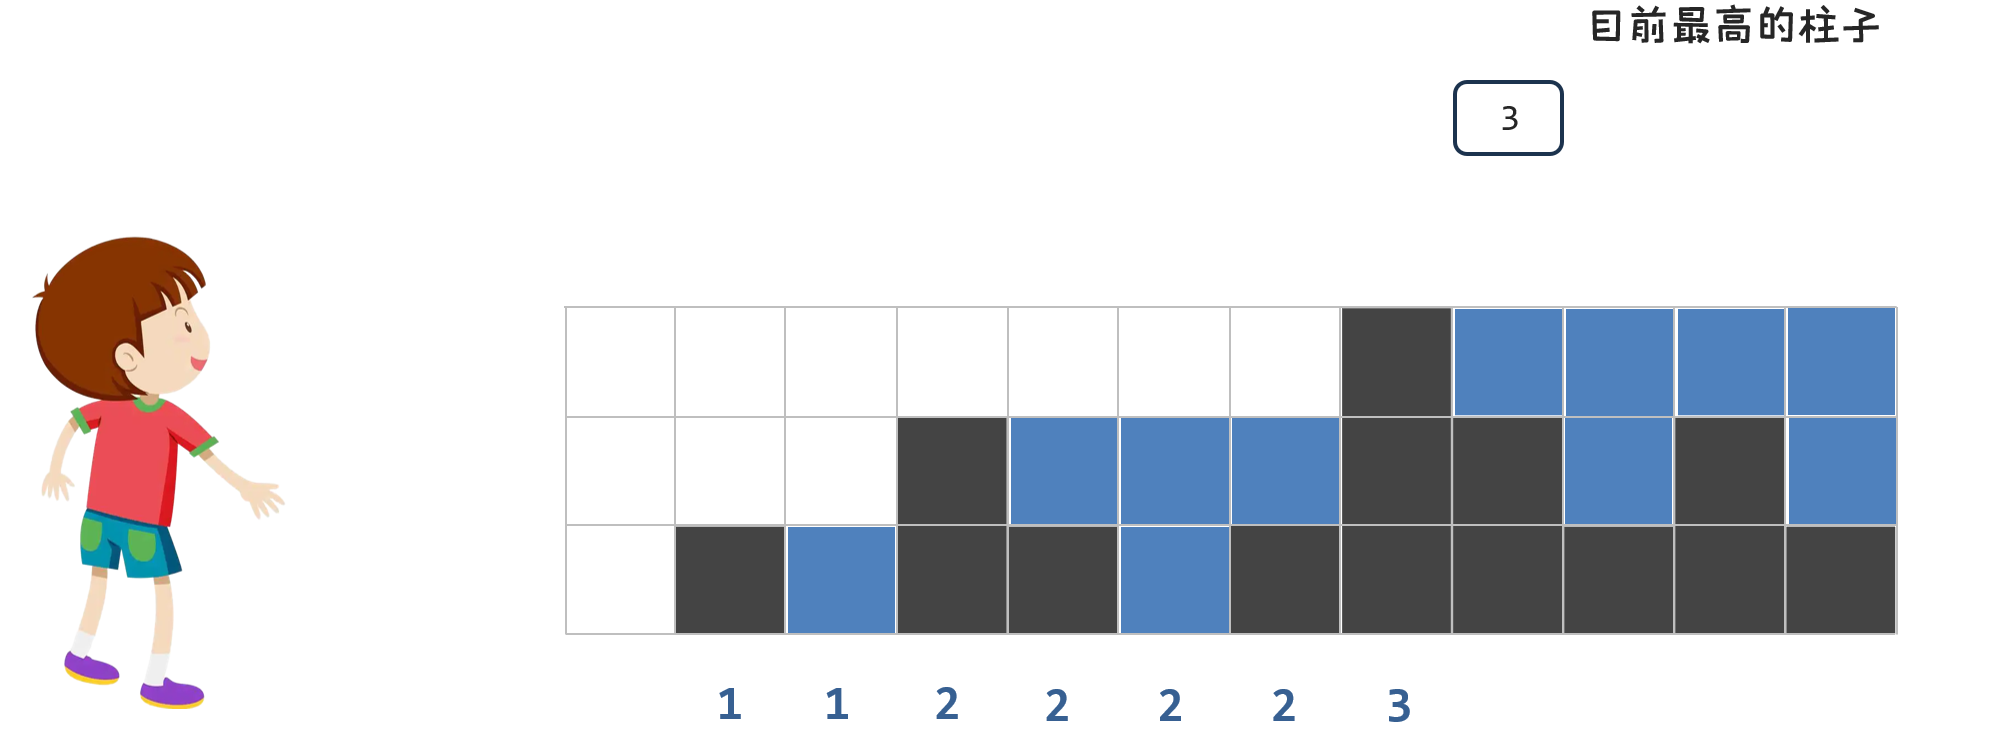

1. 同理，从右往左，也是一样的逻辑，只不过就是倒着遍历，这样就可以获取到两组数据。如图所示：

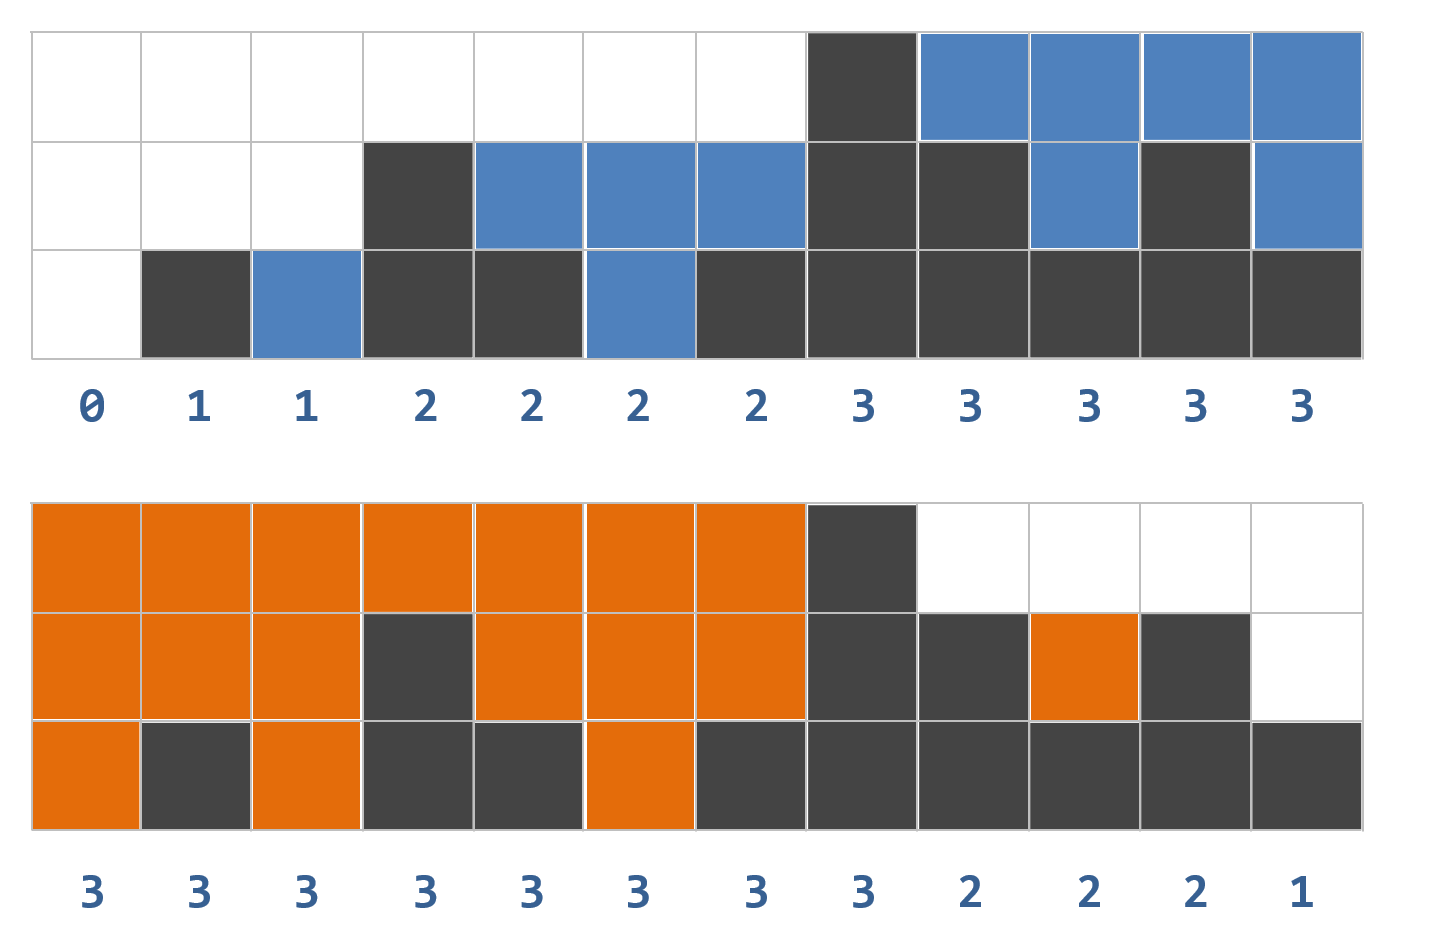

1. 合并两个数组，取最小值。

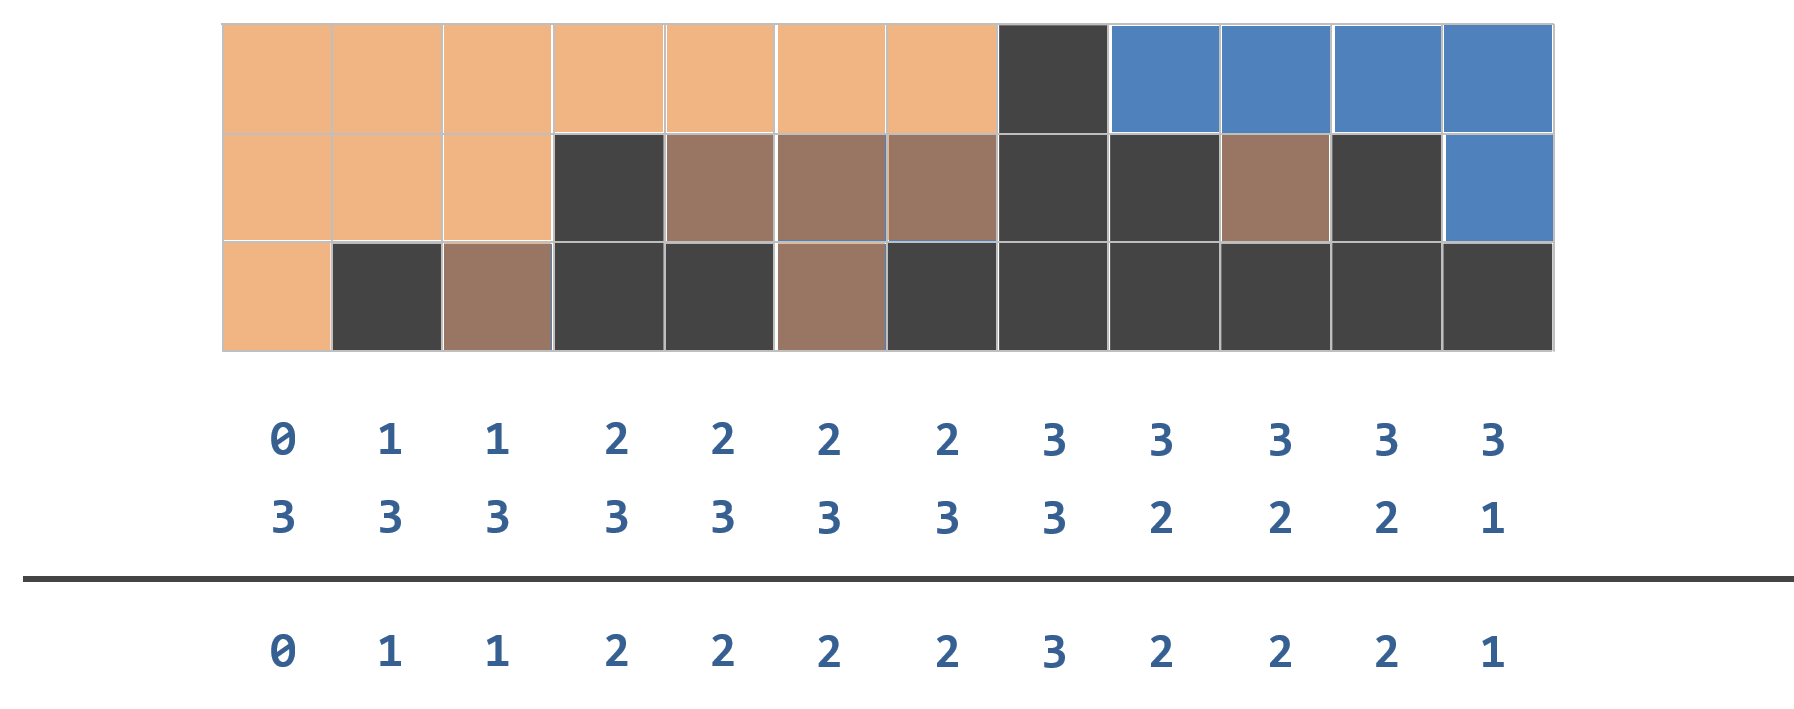

1. 减去柱子的高度，就是最终的结果。

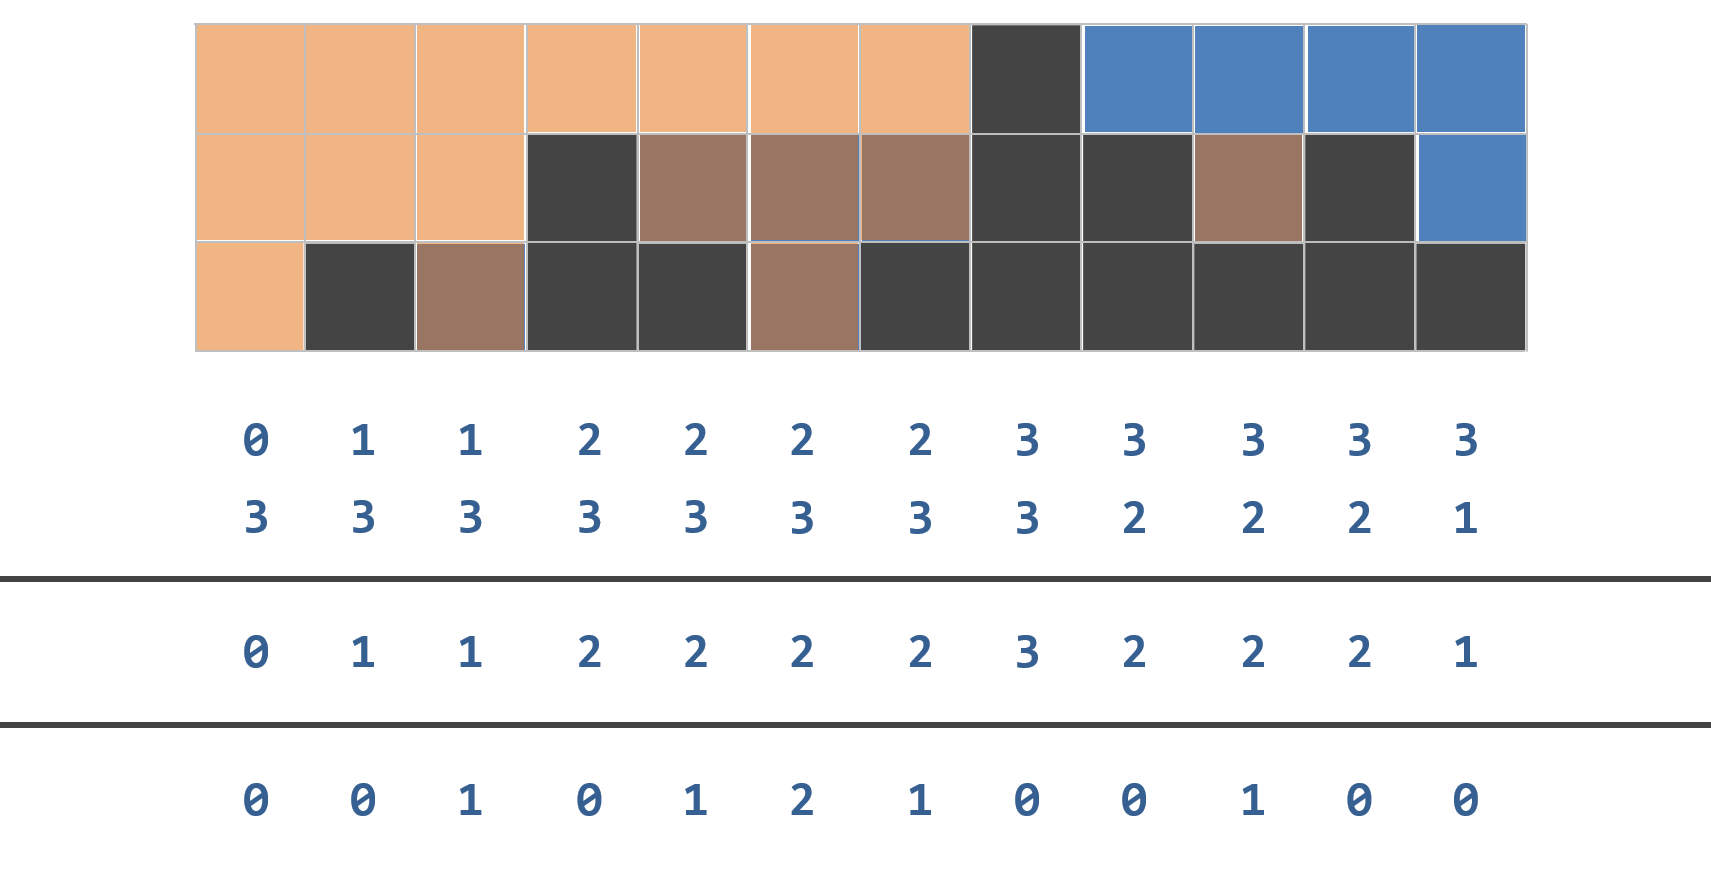

### 代码示例：

````java
package com.itheima.test;

public class Test5 {
    public static void main(String[] args) {
      /*
        给定 n 个非负整数表示每个宽度为 1 的柱子的高度图，计算按此排列的柱子，下雨之后能接多少雨水
        输入：height = [0,1,0,2,1,0,1,3,2,1,2,1]
        输出：6
        解释：下面是由数组 [0,1,0,2,1,0,1,3,2,1,2,1] 表示的高度图，在这种情况下，可以接 6 个单位的雨水（蓝色部分表示雨水）
      */

        // 1. 定义数组
        int[] arr = {0, 1, 0, 2, 1, 0, 1, 3, 2, 1, 2, 1};

        // 2. 从左往右遍历,记录雨水 + 柱子的面积总和
        // 2.1 定义数组记录从左往右看的数据
        int[] leftMax = new int[arr.length];

        // 2.2 定义第三方变量temp，记录当前最高的柱子
        int temp = arr[0];

        // 2.3 遍历数组
        for (int i = 0; i < arr.length; i++) {
            // 判断 temp  数组里面的数据
            if(temp > arr[i]){
                leftMax[i] = temp;
            }else{
                leftMax[i] = arr[i];
                temp = arr[i];
            }
        }

        // 3. 从右往左遍历,记录雨水 + 柱子的面积总和
        int[] rightMax = new int[arr.length];
        temp = arr[arr.length - 1];

        for (int i = arr.length - 1; i >= 0; i--) {
            if(temp > arr[i]){
                rightMax[i] = temp;
            }else{
                rightMax[i] = arr[i];
                temp = arr[i];
            }
        }

        // 4. 取交集
        int[] result = new int[arr.length];

        for (int i = 0; i < rightMax.length; i++) {
            // leftMax[i]: 从左到右数组中的数据
            // rightMax[i]: 从右到左数组中的数据
            if(leftMax[i] < rightMax[i]){
                result[i] = leftMax[i];
            }else{
                result[i] = rightMax[i];
            }
        }

       // 5. 求和
        int sum = 0;
        for (int i = 0; i < result.length; i++) {
            sum = sum + result[i];
        }

        // 6. 去掉柱子的面积
        for (int i = 0; i < arr.length; i++) {
            sum = sum - arr[i];
        }

        System.out.println(sum);
    }
}
````

> **补充：**该示例会直接读取 `arr[0]` 和最后一个元素，因此需要非空数组。若整理成通用方法，可对长度小于 `3` 的数组直接返回 `0`，因为不足三根柱子无法围出积水。本例总积水量为 `6`。


## 综合练习六：大乐透

### 需求：

<strong>号码介绍：</strong>

大乐透选号规则明确规定:同一投注区内的号码不可重复，但不同投注区之间允许号码重复。具体规则可分为前区和后区两个维度:

大乐透选号重复规则详解

1.前区号码不可重复。

- 投注范围:从01-35中选择5个号码。
- 规则要求:所选5个号码之间不可出现重复数字，如出现重复则该注视为无效投注。

2.后区号码不可重复。

- 投注范围:从01-12中选择2个号码。
- 规则要求:所选2个号码之间不可重复，否则同样视为无效投注。跨区重复规则。

前区与后区号码允许交叉重复，例如前区选10，后区也可选10。系统自动判定:跨区重复不会触发错误提示，属于有效投注。

玩法知识延伸

基本结构：采用"5+2"双区投注模式，前区35选5与后区12选2组合形成完整投注号码。

无效投注判定：同一区内重复号码在开奖前会被系统自动识别为无效票，无法参与兑奖。

策略提醒：虽然跨区重复有效，但统计显示前区与后区号码重复率仅3.8%，建议选号时优先考虑号码分布合理性。

> **勘误：**讲义未给出“3.8%”的统计来源，不能据此得出某种选号方式更容易中奖。在前、后区均按规则独立、公平随机开奖的模型下，每个合法的完整号码组合被开出的概率相同。

<strong>中奖规则：</strong>

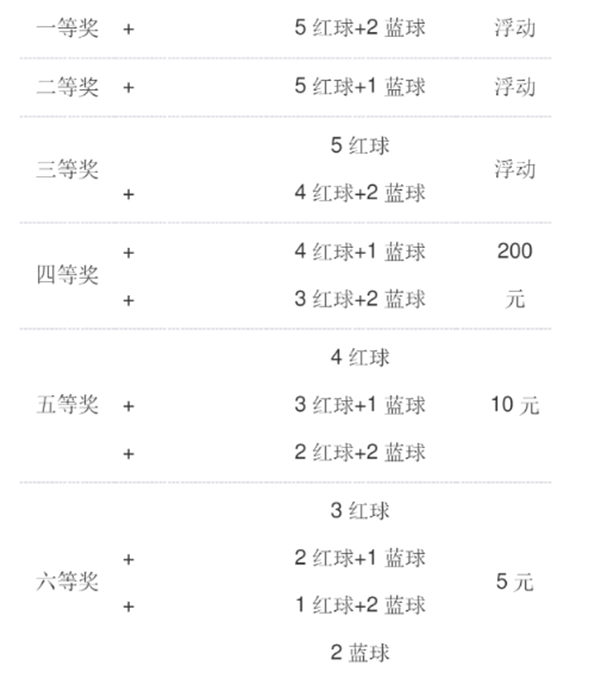

### <strong>思路分析：</strong>

本题其实就是能理解大乐透彩票号码的规则即可：

- 前五个号码（也叫红球）：01-35中选择5个号码，数据不能重复。
- 后两个号码（也叫蓝球）：01-12中选择2个号码，数据不能重复。
- 但是同一个号码在红球中选择后，蓝球中也可以选择。

号码结构如下：

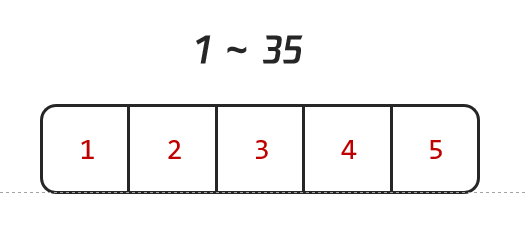

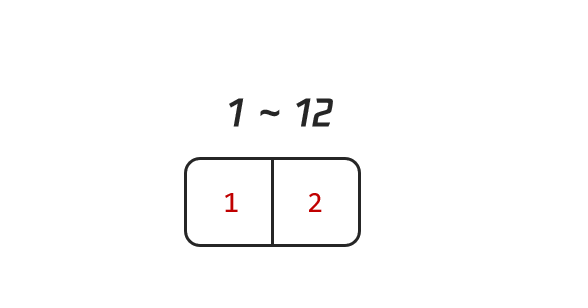

- 中奖规则：

一等奖：5 + 2<br>二等奖：5 + 1<br>三等奖：5 + 0 / 4 + 2<br>四等奖：4 + 1 / 3 + 2<br>五等奖：4 + 0 / 3 + 1 / 2 + 2<br>六等奖：3 + 0 / 1 + 2 / 2 + 1 / 0 + 2

### 代码示例：

````java
public class Test6 {
    public static void main(String[] args) {
        // 1. 利用Random随机,生成彩票号码
        int[] lotteryNumber = createLotteryNumber();
        printLotteryNumber(lotteryNumber);

        // 2. 利用Scanner模拟购买彩票
        int[] mylotteryNumber = buyLotteryNumber();
        printLotteryNumber(mylotteryNumber);

        // 3.判断中奖
        // 判断中了几个前区 (红球)
        // 判断中了几个后区 (蓝球)
        getWinnerNumber(lotteryNumber, mylotteryNumber);

    }

    // 作用:判断arr2里面的数据,在arr1中出现了几次
    // arr1: 真正的彩票号码
    // arr2: 用户购买的彩票号码
    public static void getWinnerNumber(int[] arr1, int[] arr2) {
        // 判断前区中了几个球
        int count1 = getCount(arr1, arr2, 0, 4);

        // 判断后区中了几个球
        int count2 = getCount(arr1, arr2, 5, 6);

        // 判断中了几等奖
        if (count1 == 5 && count2 == 2) {
            System.out.println("恭喜你,中奖了一等奖");
        } else if (count1 == 5 && count2 == 1) {
            System.out.println("恭喜你,中奖了二等奖");
        } else if (count1 == 5 && count2 == 0 || count1 == 4 && count2 == 2) {
            System.out.println("恭喜你,中奖了三等奖");
        } else if (count1 == 4 && count2 == 1 || count1 == 3 && count2 == 2) {
            System.out.println("恭喜你,中奖了四等奖");
        } else if (count1 == 4 && count2 == 0 || count1 == 3 && count2 == 1 || count1 == 2 && count2 == 2) {
            System.out.println("恭喜你,中奖了五等奖");
        } else if (count1 == 3 && count2 == 0 || count1 == 2 && count2 == 1 || count1 == 1 && count2 == 2 || count1 == 0 && count2 == 2) {
            System.out.println("恭喜你,中奖了六等奖");
        } else {
            System.out.println("恭喜你,没有中奖");
        }
    }

    // 判断前区或者后区中了几个球
    public static int getCount(int[] arr1, int[] arr2, int start, int end) {
        int count = 0;

        for (int i = start; i <= end; i++) { // 0 1 2 3 4
            // arr2[i] 到arr1判断,是否存在
            boolean flag = contains(arr2[i], arr1, start, end);
            // 如果当前的数字已存在, 表示中了一个号码
            if (flag) {
                count++;
            }
        }
        // 当循环结束之后,我就知道了,在start ~ end之间,中了几个号码
        return count;
    }

    public static int[] buyLotteryNumber() {
        // 1. 创建一个数组
        int[] arr = new int[7];

        // 2. 利用Scanner模拟购买彩票,1 ~ 35 选5个号码（唯一）
        Scanner sc = new Scanner(System.in);
        for (int i = 0; i < 5; ) {
            System.out.println("请输入第" + (i + 1) + "个彩票号码:");
            int number = sc.nextInt();
            // 范围
            if (number < 1 || number > 35) {
                System.out.println("当前彩票号码不在范围当中,请重新选择~");
                continue;
            }

            // 唯一
            boolean flag = contains(number, arr, 0, 4);
            if (flag) {
                System.out.println("当前彩票号码已存在,请重新选择~");
                continue;
            }

            // 如果代码能执行到这里,表示number是在范围当中的,而且数据是唯一的\
            arr[i] = number;
            i++;
        }

        // 3. 利用Scanner模拟购买彩票,1~ 12 选2个号码（唯一）
        for (int i = 0; i < 2; ) {
            System.out.println("请输入第" + (i + 1) + "个彩票号码:");
            int number = sc.nextInt();
            // 范围
            if (number < 1 || number > 12) {
                System.out.println("当前彩票号码不在范围当中,请重新选择~");
                continue;
            }
            // 唯一
            boolean flag = contains(number, arr, 5, 6);
            if (flag) {
                System.out.println("当前彩票号码已存在,请重新选择~");
                continue;
            }
            arr[i + 5] = number;
            i++;
        }
        return arr;
    }

    public static int[] createLotteryNumber() {
        // 1. 创建数组
        int[] arr = new int[7];

        // 2. 利用Random生成彩票号码,先生成前区的五个号码,1 ~ 35 选5个号码（唯一）
        Random r = new Random();
        for (int i = 0; i < 5; ) {
            int number = r.nextInt(1, 36);
            // 在前面的五个数据中,判断number是否唯一 0 ~ 4
            boolean flag = contains(number, arr, 0, 4);
            if (!flag) {
                arr[i] = number;
                i++;
            }
        }
        // 3. 利用Random生成彩票号码,先生成后区的五个号码,1~ 12 选2个号码（唯一）
        for (int i = 0; i < 2; ) {
            int number = r.nextInt(1, 13);
            // 在后面两个数据中,判断number是否唯一 5 ~ 6
            boolean flag = contains(number, arr, 5, 6);
            // 判断
            if (!flag) {
                arr[i + 5] = number;
                i++;
            }
        }
        return arr;

    }

    public static boolean contains(int number, int[] arr, int start, int end) {
        for (int i = start; i <= end; i++) {
            if (arr[i] == number) {
                return true;
            }
        }
        return false;
    }


    public static void printLotteryNumber(int[] arr) {
        System.out.print("[");
        for (int i = 0; i < arr.length; i++) {
            if (i == arr.length - 1) {
                System.out.print(arr[i]);
            } else {
                System.out.print(arr[i] + ", ");
            }
        }
        System.out.println("]");
    }
}
````

> **勘误：**`createLotteryNumber` 的注释“先生成后区的五个号码”应为“生成后区的两个号码”；循环次数和数组索引的代码是正确的。`getCount` 分别在 `[0, 4]`、`[5, 6]` 两个闭区间内统计，号码只要在同区出现就算命中，不要求排列位置一致。
